In [ ]:
import kagglehub

path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset path: /kaggle/input/celeba-dataset


In [ ]:
import os

DATASET_PATH = os.path.join(path, "img_align_celeba", "img_align_celeba")

print("Exists:", os.path.exists(DATASET_PATH))
print("Sample files:", os.listdir(DATASET_PATH)[:5])

Exists: True
Sample files: ['083648.jpg', '168202.jpg', '125778.jpg', '059339.jpg', '032501.jpg']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random

IMG_SIZE = 64
LATENT_DIM = 100
BATCH_SIZE = 32
EPOCHS = 100

In [ ]:
def load_images(path, limit=1000):
    images = []
    files = [f for f in os.listdir(path) if f.endswith(".jpg")]

    for file in files[:limit]:
        img = cv2.imread(os.path.join(path, file))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        images.append(img)

    return np.array(images)

real_images = load_images(DATASET_PATH, 1000)
print(real_images.shape)

(1000, 64, 64, 3)


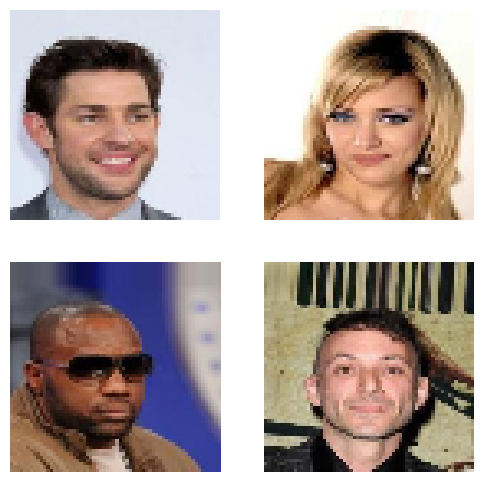

In [ ]:
plt.figure(figsize=(6,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(real_images[i])
    plt.axis("off")
plt.show()

In [ ]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=LATENT_DIM),
        layers.Dense(512, activation='relu'),
        layers.Dense(IMG_SIZE*IMG_SIZE*3, activation='sigmoid'),
        layers.Reshape((IMG_SIZE, IMG_SIZE, 3))
    ])
    return model

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False

gan_input = tf.keras.Input(shape=(LATENT_DIM,))
fake = generator(gan_input)
gan_output = discriminator(fake)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
def train(epochs, batch_size):
    for epoch in range(epochs):

        noise = np.random.normal(0,1,(batch_size, LATENT_DIM))
        fake_images = generator.predict(noise, verbose=0)

        idx = np.random.randint(0, real_images.shape[0], batch_size)
        real_batch = real_images[idx]

        X = np.concatenate([real_batch, fake_images])
        y = np.concatenate([np.ones((batch_size,1)), np.zeros((batch_size,1))])

        discriminator.trainable = True
        d_loss = discriminator.train_on_batch(X, y)

        noise = np.random.normal(0,1,(batch_size, LATENT_DIM))
        y_gen = np.ones((batch_size,1))

        discriminator.trainable = False
        g_loss = gan.train_on_batch(noise, y_gen)

        if epoch % 20 == 0:
            print(epoch, d_loss, g_loss)

train(EPOCHS, BATCH_SIZE)

0 [array(0.70176876, dtype=float32), array(0.578125, dtype=float32)] 0.6086426
20 [array(1.0187873, dtype=float32), array(0.6063988, dtype=float32)] 1.9984103
40 [array(0.53514713, dtype=float32), array(0.7980183, dtype=float32)] 4.2929254
60 [array(0.55062056, dtype=float32), array(0.7976435, dtype=float32)] 4.992455
80 [array(0.45192394, dtype=float32), array(0.83989197, dtype=float32)] 4.527009


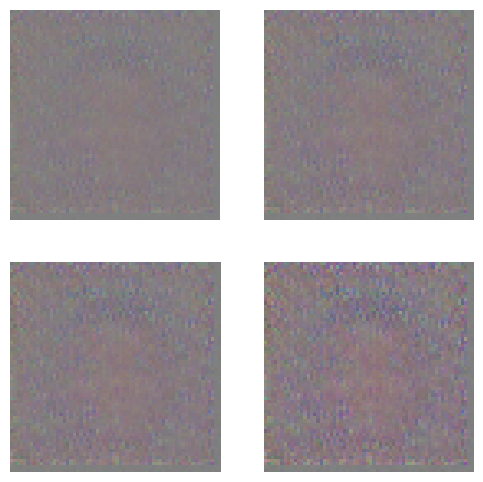

In [ ]:
def show_fake():
    noise = np.random.normal(0,1,(4, LATENT_DIM))
    imgs = generator.predict(noise, verbose=0)

    plt.figure(figsize=(6,6))
    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.imshow(imgs[i])
        plt.axis("off")
    plt.show()

show_fake()

In [ ]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = discriminator.predict(img)[0][0]

    if pred > 0.5:
        print("Real Image", pred)
    else:
        print("Fake Image", pred)

In [ ]:
files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".jpg")]
sample = os.path.join(DATASET_PATH, random.choice(files))

predict_image(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
Real Image 0.999985
